# FedProx + SCWA: Size-Composition Weighted Aggregation
## Phase 4 — Federated Small-Lesion Dice Fairness (FeTS 2022)
---
**Novel contribution:** SCWA upweights clients rich in small-lesion training data at
aggregation time. One hyperparameter `alpha`. Computed once before training. Zero
per-round overhead. Any improvement in small-dice over baseline is directly attributable
to SCWA.

**All 7 Phase-3 failures fixed:**
1. Stratified val split — small lesions in every client val set
2. Two-stage pipeline — deterministic preprocessing cached; random augmentation fresh each access
3. Larger model channels (32,64,128,256,320) ~18M params
4. 75 rounds (was 20)
5. Enhanced augmentation: flips + noise + intensity scale/shift
6. Fixed FocalTversky beta=0.8 gamma=2.0 lambda=0.5 (non-adaptive)
7. SWI overlap=0.75; harmonic-mean model selection


## 1. Install and mount

In [1]:
!pip -q install monai nibabel
from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.1 MB/s eta 0:00:00
Mounted at /content/drive


## 1b. Clean up old Drive cache (run once)

Old notebook versions saved the preprocessing cache to Drive (5-35 GB each). Run this once to delete those folders and reclaim space. Safe to skip if not needed.

In [ ]:
import shutil
from pathlib import Path

# Deletes old cache folders accidentally saved to Drive by previous notebook versions.
# Current notebook caches to local /content/ only — zero Drive usage.
drive_root = Path('/content/drive/MyDrive')
freed = 0
for folder in drive_root.glob('fets_scwa_cache_*'):
    if folder.is_dir():
        sz = sum(f.stat().st_size for f in folder.rglob('*') if f.is_file())
        shutil.rmtree(str(folder))
        freed += sz
        print(f"Deleted: {folder.name}  ({sz/1e9:.2f} GB)")

if freed == 0:
    print("No old Drive cache folders found.")
else:
    print(f"Total freed: {freed/1e9:.2f} GB")
print("Cache is now local-only — zero Drive quota used.")


## 2. Imports

In [2]:
import os, re, gc, json, math, copy, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn

from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    ConcatItemsd, DeleteItemsd, CropForegroundd, SpatialPadd,
    RandCropByPosNegLabeld, RandFlipd, RandGaussianNoised,
    RandScaleIntensityd, RandShiftIntensityd, ToTensord,
)
from monai.data import Dataset, PersistentDataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try: torch.set_float32_matmul_precision('high')
    except Exception: pass


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda


## 3. Configuration

In [6]:
# ===== paths =====
TRAIN_ROOT       = Path('/content/drive/MyDrive/FeTS_unzipped/train/MICCAI_FeTS2022_TrainingData')
PARTITIONS_JSON  = Path('/content/drive/MyDrive/final_data_partitions.json')
STATS_CSV_CANDIDATES = [
    Path('/content/master_lesion_stats.csv'),
    Path('/content/drive/MyDrive/master_lesion_stats.csv'),
]
# ---- OUTPUT: your shared folder (shortcut in MyDrive) ----
# Files written here count against the folder OWNER (Pro account), not your 15GB.
# Do NOT change this to Shareddrives/ — that only works for Workspace Team Drives.
OUTPUT_DIR = Path('/content/drive/MyDrive/fets_scwa_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- CACHE on local SSD (fast, free, rebuilt each session ~10 min) ----
# NOT on Drive — cache can be 5-35 GB which would fill your quota.
CACHE_VERSION = 'v1_scwa'
CACHE_DIR = Path(f'/content/fets_scwa_cache_{CACHE_VERSION}')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ===== experiments =====
# Default: baseline vs SCWA a=0.5
# Full ablation: ['fedavg_baseline','fedprox_scwa_a03','fedprox_scwa_a05','fedprox_scwa_a07']
EXPERIMENTS_TO_RUN = ['fedavg_baseline']

METHOD_PRESETS = {
    'fedavg_baseline':  {'use_prox': False, 'use_lft': False, 'use_scwa': False, 'prox_mu': 0.0,  'scwa_alpha': 0.5},
    'fedprox_scwa_a03': {'use_prox': True,  'use_lft': True,  'use_scwa': True,  'prox_mu': 0.01, 'scwa_alpha': 0.3},
    'fedprox_scwa_a05': {'use_prox': True,  'use_lft': True,  'use_scwa': True,  'prox_mu': 0.01, 'scwa_alpha': 0.5},
    'fedprox_scwa_a07': {'use_prox': True,  'use_lft': True,  'use_scwa': True,  'prox_mu': 0.01, 'scwa_alpha': 0.7},
}

# ===== partitioning =====
N_CLIENTS         = 5
DIRICHLET_ALPHA   = 0.5
CLIENT_MAX_CASES  = 80     # cap per client — matches Phase 3 pool size
VAL_PER_CLIENT    = 10
SMALL_THRESH_CM3  = 30.0
MEDIUM_THRESH_CM3 = 100.0

# ===== hardware =====
GPU_TOTAL_GB = 0.0
if torch.cuda.is_available():
    GPU_TOTAL_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
HIGH_VRAM          = GPU_TOTAL_GB >= 30.0
TRAIN_BATCH_SIZE   = 4 if HIGH_VRAM else 2
TRAIN_PATCHES_PER  = 4
TRAIN_POS          = 3
TRAIN_NEG          = 1
# NUM_WORKERS=2 with pin_memory=False: overlaps CPU augmentation with GPU compute.
# PersistentDataset on SSD is pickle-safe across workers.
NUM_WORKERS        = 2

# ===== model =====
MODEL_CHANNELS  = (32, 64, 128, 256, 320)   # ~18M params (was 4.7M)
MODEL_STRIDES   = (2, 2, 2, 2)
MODEL_RES_UNITS = 2

# ===== training =====
ROUNDS        = 50
LOCAL_EPOCHS  = 3
LR            = 1e-4
WD            = 1e-5
ROI_SIZE      = (96, 96, 96)
USE_AMP       = torch.cuda.is_available()
USE_CL        = torch.cuda.is_available()   # channels_last_3d

# ===== evaluation =====
SW_BATCH_SIZE    = 8 if HIGH_VRAM else 4
SW_OVERLAP       = 0.75   # final test (high-quality)
VAL_SW_OVERLAP   = 0.50   # training val checkpoint selection only
THRESHOLD        = 0.5
FULL_VAL_EVERY_N = 10

# ===== loss (fixed, non-adaptive) =====
LFT_ALPHA   = 0.3
LFT_BETA    = 0.8    # FN penalty 2.67x FP (was 0.7)
LFT_GAMMA   = 2.0    # focal exponent (was 1.33)
LAMBDA_LFT  = 0.5    # fixed weight — not adaptive

print(f'Device: {device} | GPU: {GPU_TOTAL_GB:.1f} GB | HIGH_VRAM: {HIGH_VRAM}')
print(f'Model channels: {MODEL_CHANNELS}')
print(f'Rounds: {ROUNDS} | Local epochs: {LOCAL_EPOCHS} | NUM_WORKERS: {NUM_WORKERS}')
print(f'Experiments: {EXPERIMENTS_TO_RUN}')


Device: cuda | GPU: 39.5 GB | HIGH_VRAM: True
Model channels: (32, 64, 128, 256, 320)
Rounds: 50 | Local epochs: 3 | NUM_WORKERS: 2
Experiments: ['fedavg_baseline']


## 4. Stats, file resolution, test set

In [7]:
def assign_group(v):
    v = float(v)
    if v < SMALL_THRESH_CM3: return 'small'
    if v <= MEDIUM_THRESH_CM3: return 'medium'
    return 'large'

def load_stats_df():
    for p in STATS_CSV_CANDIDATES:
        if Path(p).exists():
            print('Stats CSV:', p); df = pd.read_csv(p); break
    else:
        raise FileNotFoundError('master_lesion_stats.csv not found in candidates')
    if 'case_id' not in df.columns:
        for col in ['case_name','path','case','subject_id']:
            if col in df.columns:
                df['case_id'] = df[col].astype(str).apply(lambda x: Path(x).name); break
        else: raise ValueError('Cannot infer case_id')
    for vol_col in ['lesion_cm3','lesion_volume_cm3']:
        if vol_col in df.columns: df['lesion_cm3'] = df[vol_col].astype(float); break
    else:
        if 'lesion_volume' in df.columns: df['lesion_cm3'] = df['lesion_volume'].astype(float)/1000
        else: raise ValueError('Cannot find lesion volume column')
    df['size_group'] = df['lesion_cm3'].apply(assign_group)
    df['case_id'] = df['case_id'].astype(str)
    return df

stats_df    = load_stats_df()
stats_index = {r['case_id']: r for _, r in stats_df.iterrows()}

MOD_KEYS = ['flair','t1','t1ce','t2']

def modality_from_name(name):
    n = name.lower()
    if 'seg' in n: return 'seg'
    if 'flair' in n: return 'flair'
    if 't1ce' in n or 't1gd' in n: return 't1ce'
    if re.search(r'(^|[_\-.])t1([_\-.]|$)', n) and 't1ce' not in n: return 't1'
    if re.search(r'(^|[_\-.])t2([_\-.]|$)', n): return 't2'
    return None

def resolve_case_files(case_dir):
    case_dir = Path(case_dir)
    found, seg = {}, None
    for f in sorted(case_dir.glob('*.nii.gz')):
        k = modality_from_name(f.name)
        if k == 'seg': seg = str(f)
        elif k: found[k] = str(f)
    missing = [k for k in MOD_KEYS if k not in found]
    if seg is None or missing:
        raise RuntimeError(f'{case_dir.name}: missing modalities={missing} seg={seg is not None}')
    return {'case_name': case_dir.name, 'case_path': str(case_dir),
            'flair': found['flair'], 't1': found['t1'],
            't1ce': found['t1ce'], 't2': found['t2'], 'label': seg}

def attach_meta(case_dir):
    case_dir = Path(case_dir); name = case_dir.name
    row = stats_index.get(name)
    if row is not None:
        return {'case_path': case_dir, 'case_name': name,
                'lesion_cm3': float(row['lesion_cm3']),
                'size_group': str(row['size_group'])}
    segs = list(case_dir.glob('*seg*.nii.gz'))
    if len(segs) != 1: raise RuntimeError(f'{name}: expected 1 seg, found {len(segs)}')
    v = float((nib.load(str(segs[0])).get_fdata() > 0).sum()) / 1000.0
    return {'case_path': case_dir, 'case_name': name,
            'lesion_cm3': v, 'size_group': assign_group(v)}

# ---- locked-box test set ----
if not PARTITIONS_JSON.exists():
    raise FileNotFoundError(f'Not found: {PARTITIONS_JSON}')
with open(PARTITIONS_JSON) as fh: meta_lb = json.load(fh)
if 'test_set_paths' not in meta_lb: raise KeyError('PARTITIONS_JSON needs test_set_paths')
test_meta = [attach_meta(p) for p in meta_lb['test_set_paths']]
print(f'Test set: {len(test_meta)} cases')
print(pd.DataFrame(test_meta)['size_group'].value_counts().to_string())


Stats CSV: /content/drive/MyDrive/master_lesion_stats.csv
Test set: 90 cases
size_group
small     30
medium    30
large     30


## 5. Dirichlet partition + stratified cap + stratified val split

- **Dirichlet alpha=0.5** creates non-IID skew across clients
- **stratified_cap(max=80)** matches Phase-3 pool size (preserves small-case scarcity)
- **Stratified val split** guarantees small cases in every client val set (fixes Phase-3 root cause)


In [8]:
if not TRAIN_ROOT.exists(): raise FileNotFoundError(f'TRAIN_ROOT not found: {TRAIN_ROOT}')
train_dirs    = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
dir_by_id     = {p.name: p for p in train_dirs}
train_df      = stats_df[stats_df['case_id'].isin(dir_by_id)].copy()
train_df['path'] = train_df['case_id'].map(dir_by_id)
train_df      = train_df.dropna(subset=['path']).copy()
if len(train_df) == 0: raise RuntimeError('No training cases matched stats CSV')
print(f'Training pool: {len(train_df)} cases')
print(train_df['size_group'].value_counts().to_string())

def dirichlet_partition(df, num_clients=5, alpha=0.5, seed=SEED):
    rng     = np.random.default_rng(seed)
    clients = {i: [] for i in range(num_clients)}
    for grp in ['small','medium','large']:
        gdf = df[df['size_group']==grp].sample(frac=1, random_state=seed)
        if len(gdf) == 0: continue
        props  = rng.dirichlet([alpha]*num_clients)
        splits = (props * len(gdf)).astype(int)
        splits[: len(gdf)-splits.sum()] += 1   # fix remainder
        start = 0
        for i in range(num_clients):
            end = start + splits[i]
            clients[i].extend([attach_meta(r['path'])
                                for _, r in gdf.iloc[start:end].iterrows()])
            start = end
    return [clients[i] for i in range(num_clients)]

def stratified_cap(meta_list, max_cases=CLIENT_MAX_CASES, seed=SEED):
    if len(meta_list) <= max_cases: return meta_list
    rng = random.Random(seed)
    by_grp = defaultdict(list)
    for m in meta_list: by_grp[m['size_group']].append(m)
    out = []
    for grp, cases in by_grp.items():
        n = max(1, round(len(cases)/len(meta_list)*max_cases))
        rng.shuffle(cases); out.extend(cases[:n])
    rng.shuffle(out)
    return out[:max_cases]

def stratified_val_split(client_meta_list, val_per_client=VAL_PER_CLIENT, seed=SEED):
    rng = random.Random(seed)
    train_by, val_by = [], []
    for meta_list in client_meta_list:
        meta_list = list(meta_list)
        total = len(meta_list)
        n_val = min(val_per_client, max(1, total//5))
        by_grp = defaultdict(list)
        for m in meta_list: by_grp[m['size_group']].append(m)
        val, train = [], []
        for grp, cases in by_grp.items():
            rng.shuffle(cases)
            n = max(0, round(len(cases)/total*n_val))
            n = min(n, len(cases))
            if len(cases) > 1 and n == 0 and len(val) < n_val: n = 1
            val.extend(cases[:n]); train.extend(cases[n:])
        if len(val) < n_val and train:
            rng.shuffle(train)
            d = n_val - len(val); val.extend(train[:d]); train = train[d:]
        train_by.append(train); val_by.append(val)
    return train_by, val_by

all_client_meta = dirichlet_partition(train_df)
all_client_meta = [stratified_cap(m, seed=SEED+i)
                   for i, m in enumerate(all_client_meta)]
train_meta_by_client, val_meta_by_client = stratified_val_split(all_client_meta)

n_cases_by_client = [len(tr) for tr in train_meta_by_client]
n_small_by_client = [sum(1 for m in tr if m['size_group']=='small')
                     for tr in train_meta_by_client]

print('\nClient distribution:')
print(f'{"C":<3}{"Tr":>5}{"Val":>5}{"S_tr":>6}{"M_tr":>6}{"L_tr":>6}'
      f'{"S_val":>7}{"M_val":>7}{"L_val":>7}')
for i in range(N_CLIENTS):
    tr = train_meta_by_client[i]; va = val_meta_by_client[i]
    c = lambda lst,g: sum(1 for m in lst if m['size_group']==g)
    print(f'{i:<3}{len(tr):>5}{len(va):>5}'
          f'{c(tr,"small"):>6}{c(tr,"medium"):>6}{c(tr,"large"):>6}'
          f'{c(va,"small"):>7}{c(va,"medium"):>7}{c(va,"large"):>7}')


Training pool: 1251 cases
size_group
medium    560
large     537
small     154

Client distribution:
C     Tr  Val  S_tr  M_tr  L_tr  S_val  M_val  L_val
0     70   10     7     4    59      1      1      8
1     70   10    20    26    24      3      4      3
2     58   10     1    55     2      0      9      1
3     70   10     9    46    15      1      7      2
4     70   10     0    66     4      0      9      1


## 6. Transforms and datasets

**Two-stage pipeline:**
- Stage 1 `preprocess_transforms` — deterministic. Cached in RAM by `CacheDataset`.
- Stage 2 `augment_transforms` — random. Applied fresh on every `__getitem__`.

Uses in-memory cache (`CacheDataset`) rather than disk (`PersistentDataset`) to avoid
filling the 112 GB local Colab disk. RAM cache (~15-25 GB) is faster and disk-free.

In [10]:
from monai.data import CacheDataset, pad_list_data_collate

# ---- Stage 1: deterministic preprocessing (cached in RAM) ----
preprocess_transforms = Compose([
    LoadImaged(keys=MOD_KEYS + ['label']),
    EnsureChannelFirstd(keys=MOD_KEYS + ['label']),
    NormalizeIntensityd(keys=MOD_KEYS, nonzero=True, channel_wise=True),
    ConcatItemsd(keys=MOD_KEYS, name='image', dim=0),
    DeleteItemsd(keys=MOD_KEYS),
    CropForegroundd(keys=['image','label'], source_key='image'),
    SpatialPadd(keys=['image','label'], spatial_size=ROI_SIZE),
    ToTensord(keys=['image','label']),
])

# ---- Stage 2: random augmentation (never cached, always fresh) ----
augment_transforms = Compose([
    RandCropByPosNegLabeld(
        keys=['image','label'], label_key='label',
        spatial_size=ROI_SIZE, pos=TRAIN_POS, neg=TRAIN_NEG,
        num_samples=TRAIN_PATCHES_PER, image_key='image', image_threshold=0.0,
    ),
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image','label'], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=['image'], prob=0.15, mean=0.0, std=0.05),
    RandScaleIntensityd(keys=['image'], factors=0.1, prob=0.3),
    RandShiftIntensityd(keys=['image'], offsets=0.1, prob=0.3),
    ToTensord(keys=['image','label']),
])

# ---- Eval transforms ----
eval_transforms = Compose([
    LoadImaged(keys=MOD_KEYS + ['label']),
    EnsureChannelFirstd(keys=MOD_KEYS + ['label']),
    NormalizeIntensityd(keys=MOD_KEYS, nonzero=True, channel_wise=True),
    ConcatItemsd(keys=MOD_KEYS, name='image', dim=0),
    DeleteItemsd(keys=MOD_KEYS),
    CropForegroundd(keys=['image','label'], source_key='image'),
    SpatialPadd(keys=['image','label'], spatial_size=ROI_SIZE),
    ToTensord(keys=['image','label']),
])

# ---- TwoStageDataset: RAM cache + shared memory for multi-worker safety ----
class TwoStageDataset(torch.utils.data.Dataset):
    def __init__(self, records, _cache_subdir=None):
        self.base = CacheDataset(
            data=records, transform=preprocess_transforms,
            cache_rate=1.0, num_workers=0, progress=True)
        # Move cached tensors to shared memory so DataLoader workers can
        # read them without copying — prevents OOM crash with num_workers>0
        for item in self.base._cache:
            if item is not None:
                for v in item.values():
                    if isinstance(v, torch.Tensor):
                        v.share_memory_()
        self.aug = augment_transforms
    def __len__(self):          return len(self.base)
    def __getitem__(self, idx): return self.aug(self.base[idx])

def build_eval_dataset(records, _cache_subdir=None):
    return CacheDataset(
        data=records, transform=eval_transforms,
        cache_rate=1.0, num_workers=0, progress=True)

def build_loader(ds, batch_size, shuffle, workers=None):
    nw = NUM_WORKERS if workers is None else workers
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=nw,
                      pin_memory=False,
                      persistent_workers=(nw > 0),
                      collate_fn=pad_list_data_collate)

def meta_to_records(meta_list):
    out = []
    for m in meta_list:
        rec = resolve_case_files(m['case_path'])
        rec['size_group'] = str(m['size_group'])
        rec['lesion_cm3'] = float(m['lesion_cm3'])
        out.append(rec)
    return out

train_records_by_client = [meta_to_records(tr) for tr in train_meta_by_client]
val_records_by_client   = [meta_to_records(va) for va in val_meta_by_client]
test_records            = meta_to_records(test_meta)

print('Building in-memory cache (loads all volumes from Drive once)...')
train_loaders, val_loaders = [], []
for i in range(N_CLIENTS):
    print(f'  Client {i} train ({len(train_records_by_client[i])} cases):', flush=True)
    tr_ds = TwoStageDataset(train_records_by_client[i])
    print(f'  Client {i} val   ({len(val_records_by_client[i])} cases):', flush=True)
    va_ds = build_eval_dataset(val_records_by_client[i])
    train_loaders.append(build_loader(tr_ds, TRAIN_BATCH_SIZE, shuffle=True))
    val_loaders.append(build_loader(va_ds, 1, shuffle=False, workers=0))

print(f'  Test ({len(test_records)} cases):', flush=True)
test_ds     = build_eval_dataset(test_records)
test_loader = build_loader(test_ds, 1, shuffle=False, workers=0)

print('All loaders ready.')
for i in range(N_CLIENTS):
    print(f'  Client {i}: train={len(train_loaders[i])} batches | val={len(val_loaders[i])} batches')
print(f'  Test: {len(test_loader)} batches')


Building in-memory cache (loads all volumes from Drive once)...
  Client 0 train (70 cases):


Loading dataset: 100%|██████████| 70/70 [04:25<00:00,  3.79s/it]


  Client 0 val   (10 cases):


Loading dataset: 100%|██████████| 10/10 [00:42<00:00,  4.25s/it]

  Client 1 train (70 cases):


...

  Client 4 val   (10 cases):


Loading dataset: 100%|██████████| 10/10 [00:37<00:00,  3.79s/it]

  Test (90 cases):



Loading dataset: 100%|██████████| 90/90 [05:19<00:00,  3.55s/it]

All loaders ready.
  Client 0: train=18 batches | val=10 batches
  Client 1: train=18 batches | val=10 batches
  Client 2: train=15 batches | val=10 batches
  Client 3: train=18 batches | val=10 batches
  Client 4: train=18 batches | val=10 batches
  Test: 90 batches


## 7. Model

In [11]:
def get_model():
    model = UNet(
        spatial_dims=3, in_channels=4, out_channels=1,
        channels=MODEL_CHANNELS, strides=MODEL_STRIDES,
        num_res_units=MODEL_RES_UNITS,
    ).to(device)
    if USE_CL:
        model = model.to(memory_format=torch.channels_last_3d)
    return model

def flatten(t):
    if t.ndim == 6: b,n,c,h,w,d = t.shape; return t.reshape(b*n,c,h,w,d)
    if t.ndim == 5: return t
    raise ValueError(f'Unexpected shape {tuple(t.shape)}')

def to_dev(x):
    x = x.to(device, non_blocking=True)
    if USE_CL: x = x.contiguous(memory_format=torch.channels_last_3d)
    return x

_m = get_model()
print(f'Model params: {sum(p.numel() for p in _m.parameters()):,}')
del _m


Model params: 12,866,830


## 8. Smoke test

In [ ]:
_b  = next(iter(train_loaders[0]))
_x  = flatten(_b['image'])
_y  = flatten(_b['label'])
print('Train batch:', tuple(_x.shape), tuple(_y.shape))
assert _x.ndim==5 and _x.shape[1]==4
assert _y.ndim==5 and _y.shape[1]==1
_pos = int((_y.view(_y.shape[0],-1).sum(1)>0).sum())
print(f'Tumor-positive patches: {_pos}/{_y.shape[0]}')
assert _pos > 0, 'No tumor-positive patches — check pos/neg sampling'

_sm = get_model(); _sm.eval()
with torch.inference_mode():
    _xd = to_dev(_x)
    _vb = next(iter(val_loaders[0])); _vx = to_dev(_vb['image'])
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        _lp = _sm(_xd)
        _ls = sliding_window_inference(
            _vx, ROI_SIZE, SW_BATCH_SIZE, _sm,
            overlap=SW_OVERLAP, mode='gaussian',
            sw_device=device, device=device)
assert _lp.shape[1]==1 and _ls.shape[1]==1
print('Smoke test PASSED.')
del _sm, _xd, _vx, _lp, _ls, _b, _vb
gc.collect(); torch.cuda.empty_cache()


## 9. Losses, metrics, SCWA

In [12]:
dice_loss_fn = DiceLoss(sigmoid=True)

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=LFT_ALPHA, beta=LFT_BETA, gamma=LFT_GAMMA, smooth=1e-5):
        super().__init__()
        self.alpha,self.beta,self.gamma,self.smooth = alpha,beta,gamma,smooth
    def forward(self, logits, target):
        p = torch.sigmoid(logits); t = target.float()
        dims = tuple(range(2, p.ndim))
        tp = (p*t).sum(dims); fp = (p*(1-t)).sum(dims); fn = ((1-p)*t).sum(dims)
        tv = (tp+self.smooth)/(tp+self.alpha*fp+self.beta*fn+self.smooth)
        return torch.pow(1-tv, self.gamma).mean()

ft_loss = FocalTverskyLoss()

def local_loss(logits, target, use_lft=True):
    d = dice_loss_fn(logits, target)
    return d + LAMBDA_LFT * ft_loss(logits, target) if use_lft else d

def hard_dice(logits, target, eps=1e-8):
    pred = (torch.sigmoid(logits) > THRESHOLD).float(); t = target.float()
    return float(2*(pred*t).sum() / (pred.sum()+t.sum()+eps))

def harmonic_mean(vals):
    vals = [v for v in vals if not (math.isnan(v) if isinstance(v,float) else False) and v>0]
    return len(vals)/sum(1/v for v in vals) if vals else 0.0

# ---- SCWA ----
def compute_scwa_weights(n_cases, n_small, alpha=0.5):
    """
    Size-Composition Weighted Aggregation.
    alpha=0 -> FedAvg | alpha=1 -> pure small-richness | alpha=0.5 -> balanced.
    """
    tc = sum(n_cases); ts = max(sum(n_small), 1)
    ws = [(1-alpha)*(nc/tc) + alpha*(ns/ts)
          for nc,ns in zip(n_cases,n_small)]
    s  = sum(ws)
    return [w/s*tc for w in ws]

print(f'FocalTversky: alpha={LFT_ALPHA} beta={LFT_BETA} gamma={LFT_GAMMA}')
print(f'Combined loss: Dice + {LAMBDA_LFT} x FocalTversky (fixed)')
print()
print('SCWA weight preview:')
print(f'{"C":<4}{"n_tot":>7}{"n_sm":>6}{"FedAvg":>9}{"a=0.3":>8}{"a=0.5":>8}{"a=0.7":>8}')
tc = sum(n_cases_by_client)
for i in range(N_CLIENTS):
    row = [i, n_cases_by_client[i], n_small_by_client[i]]
    for a in [0.0,0.3,0.5,0.7]:
        w = compute_scwa_weights(n_cases_by_client, n_small_by_client, a)
        row.append(w[i]/tc*100)
    print(f'{row[0]:<4}{row[1]:>7}{row[2]:>6}'
          f'{row[3]:>8.1f}%{row[4]:>7.1f}%{row[5]:>7.1f}%{row[6]:>7.1f}%')


FocalTversky: alpha=0.3 beta=0.8 gamma=2.0
Combined loss: Dice + 0.5 x FocalTversky (fixed)

SCWA weight preview:
C     n_tot  n_sm   FedAvg   a=0.3   a=0.5   a=0.7
0        70     7    20.7%   20.2%   19.8%   19.5%
1        70    20    20.7%   30.7%   37.4%   44.1%
2        58     1    17.2%   12.8%    9.9%    7.0%
3        70     9    20.7%   21.8%   22.5%   23.2%
4        70     0    20.7%   14.5%   10.4%    6.2%


## 10. Aggregation and local training

In [13]:
def aggregate(state_dicts, weights):
    total = float(sum(weights))
    agg   = copy.deepcopy(state_dicts[0])
    for key in agg:
        is_int = not torch.is_floating_point(state_dicts[0][key])
        acc = None
        for sd, w in zip(state_dicts, weights):
            t = sd[key].float() * (w/total)
            acc = t if acc is None else acc + t
        agg[key] = acc.round().to(state_dicts[0][key].dtype) if is_int \
                   else acc.to(state_dicts[0][key].dtype)
    return agg

def train_client(model, global_ref, loader, optimizer,
                 local_epochs, prox_mu=0.0, use_lft=True):
    model.train()
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    ref    = None
    if prox_mu > 0:
        ref = {n: p.detach().clone() for n,p in global_ref.named_parameters()}
    logs = []
    for ep in range(local_epochs):
        losses = []
        for batch in loader:
            x = to_dev(flatten(batch['image']))
            y = (flatten(batch['label']).to(device, non_blocking=True)>0).float()
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(x)
                loss   = local_loss(logits, y, use_lft=use_lft)
                if prox_mu > 0:
                    prox = sum(((p-ref[n])**2).sum() for n,p in model.named_parameters())
                    loss = loss + 0.5*prox_mu*prox
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            losses.append(float(loss.detach()))
        logs.append(float(np.mean(losses)))
    return logs


## 11. Evaluation

In [14]:
@torch.inference_mode()
def predict_volume(model, image, overlap=SW_OVERLAP):
    model.eval()
    try:
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            return sliding_window_inference(
                image, ROI_SIZE, SW_BATCH_SIZE, model,
                overlap=overlap, mode='gaussian',
                sw_device=device, device=device)
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            torch.cuda.empty_cache()
            return sliding_window_inference(
                image, ROI_SIZE, 1, model,
                overlap=overlap, mode='gaussian',
                sw_device=device, device=device)
        raise

@torch.inference_mode()
def evaluate(model, loader, records, overlap=SW_OVERLAP):
    assert len(loader.dataset)==len(records), \
        f'Record/dataset mismatch: {len(loader.dataset)} vs {len(records)}'
    model.eval()
    scores, by_grp = [], defaultdict(list)
    for idx, batch in enumerate(loader):
        rec    = records[idx]
        x      = to_dev(batch['image'])
        y      = (batch['label'].to(device, non_blocking=True)>0).float()
        logits = predict_volume(model, x, overlap=overlap)
        d      = hard_dice(logits, y)
        scores.append(d); by_grp[rec['size_group']].append(d)
    def gm(g): v=by_grp.get(g,[]); return float(np.mean(v)) if v else float('nan')
    s,m,lg = gm('small'), gm('medium'), gm('large')
    return {'mean_dice': float(np.mean(scores)) if scores else 0.0,
            'small_dice': s, 'medium_dice': m, 'large_dice': lg,
            'fair_score': harmonic_mean([s,m,lg]),
            'n_cases': len(scores)}

def eval_all_clients(model, overlap=VAL_SW_OVERLAP):
    rows = []
    for i in range(N_CLIENTS):
        m = evaluate(model, val_loaders[i], val_records_by_client[i], overlap=overlap)
        m['client_id'] = i; rows.append(m)
    df = pd.DataFrame(rows)
    def nm(col): v=df[col].dropna().tolist(); return float(np.mean(v)) if v else float('nan')
    s,m,lg = nm('small_dice'), nm('medium_dice'), nm('large_dice')
    return {'val_mean_dice':   float(df['mean_dice'].mean()),
            'val_worst_dice':  float(df['mean_dice'].min()),
            'val_small_dice':  s,
            'val_medium_dice': m,
            'val_large_dice':  lg,
            'val_fair_score':  harmonic_mean([s,m,lg]),
            'val_fairness_gap':float(df['mean_dice'].mean()-df['mean_dice'].min())}


## 12. Federated experiment runner

In [15]:
def run_experiment(method_name):
    cfg = METHOD_PRESETS[method_name]
    print('='*70); print(f'  {method_name.upper()}'); print('='*70)

    exp_dir  = OUTPUT_DIR / method_name
    ckpt_dir = exp_dir / 'checkpoints'
    exp_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # SCWA weights computed ONCE before training
    if cfg['use_scwa']:
        agg_w = compute_scwa_weights(n_cases_by_client, n_small_by_client,
                                      alpha=cfg['scwa_alpha'])
        print(f'SCWA weights (alpha={cfg["scwa_alpha"]}):', [f'{w:.2f}' for w in agg_w])
    else:
        agg_w = [float(n) for n in n_cases_by_client]
        print('FedAvg weights:', agg_w)

    global_model   = get_model()
    best_score     = -1.0
    best_round     = -1
    best_val       = None
    best_sd        = copy.deepcopy(global_model.state_dict())
    history_rows   = []

    for rnd in range(1, ROUNDS+1):
        print(f'\nRound {rnd}/{ROUNDS}')

        # --- local training ---
        local_sds = []
        for cid in range(N_CLIENTS):
            print(f'  Client {cid}...', end=' ')
            lm  = copy.deepcopy(global_model)
            opt = torch.optim.Adam(lm.parameters(), lr=LR, weight_decay=WD)
            logs = train_client(
                lm, global_model, train_loaders[cid], opt,
                LOCAL_EPOCHS,
                prox_mu = cfg['prox_mu'] if cfg['use_prox'] else 0.0,
                use_lft = cfg['use_lft'],
            )
            local_sds.append(lm.state_dict())
            print(f'loss={logs[-1]:.4f}')
            del lm

        # --- aggregation ---
        global_model.load_state_dict(aggregate(local_sds, agg_w))

        # --- validation (every FULL_VAL_EVERY_N rounds) ---
        do_val = (rnd % FULL_VAL_EVERY_N == 0) or (rnd == ROUNDS)
        row = {'round': rnd, 'full_val': do_val}

        if do_val:
            print(f'  Validating...')
            vs = eval_all_clients(global_model)
            row.update(vs)
            print(f'  mean={vs["val_mean_dice"]:.4f} '
                  f'small={vs["val_small_dice"]:.4f} '
                  f'medium={vs["val_medium_dice"]:.4f} '
                  f'large={vs["val_large_dice"]:.4f} '
                  f'fair={vs["val_fair_score"]:.4f}')

            if vs['val_fair_score'] > best_score:
                best_score = vs['val_fair_score']
                best_round = rnd; best_val = vs
                best_sd    = copy.deepcopy(global_model.state_dict())
                torch.save({'round': rnd, 'state_dict': best_sd,
                            'val_fair_score': best_score},
                           str(ckpt_dir/f'{method_name}_best.pt'))
                print(f'  ** New best fair_score={best_score:.4f} (round {rnd})')

            # flush history to Drive after every val (crash-safe)
            pd.DataFrame(history_rows+[row]).to_csv(
                exp_dir/f'{method_name}_history.csv', index=False)

            gc.collect(); torch.cuda.empty_cache()

        history_rows.append(row)

        # save latest checkpoint every 10 rounds (crash recovery)
        if rnd % 10 == 0:
            torch.save({'round': rnd,
                        'state_dict': global_model.state_dict(),
                        'best_round': best_round,
                        'best_fair_score': best_score,
                        'agg_weights': agg_w},
                       str(ckpt_dir/f'{method_name}_latest.pt'))

    # --- test evaluation ---
    print('\nTest evaluation with best model...')
    global_model.load_state_dict(best_sd)
    tm = evaluate(global_model, test_loader, test_records, overlap=SW_OVERLAP)
    sm, mm, lm_ = tm['small_dice'], tm['medium_dice'], tm['large_dice']
    tm['small_gap'] = float(np.nanmean([mm, lm_])) - sm \
                      if not math.isnan(sm) else float('nan')

    print(f'Test mean={tm["mean_dice"]:.4f} '
          f'small={sm:.4f} medium={mm:.4f} '
          f'large={lm_:.4f} fair={tm["fair_score"]:.4f}')

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(exp_dir/f'{method_name}_history.csv', index=False)
    pd.DataFrame([{'method': method_name, 'best_round': best_round,
                   'best_val_fair': best_score, **{f'test_{k}':v
                   for k,v in tm.items()}}]).to_csv(
        exp_dir/f'{method_name}_test_metrics.csv', index=False)

    return {'method': method_name, 'best_round': best_round,
            'best_fair_score': best_score, 'best_val': best_val,
            'test': tm, 'history_df': history_df, 'agg_weights': agg_w}


## 13. Run experiments

In [16]:
results = {}
for method in EXPERIMENTS_TO_RUN:
    results[method] = run_experiment(method)
    gc.collect(); torch.cuda.empty_cache()

print('\n'+'='*70)
print('DONE')
for k, v in results.items():
    tm = v['test']
    print(f'{k:<28} best_round={v["best_round"]:>3} '
          f'test_mean={tm["mean_dice"]:.4f} '
          f'test_small={tm["small_dice"]:.4f} '
          f'fair={tm["fair_score"]:.4f}')


  FEDAVG_BASELINE
FedAvg weights: [70.0, 70.0, 58.0, 70.0, 70.0]

Round 1/50
  Client 0... loss=0.7072
  Client 1... loss=0.8045
  Client 2... loss=0.8180
  Client 3... loss=0.8041
  Client 4... loss=0.8098

Round 2/50
  Client 0... loss=0.7055
  Client 1... loss=0.7994
  Client 2... loss=0.8052
  Client 3... loss=0.7896
  Client 4... loss=0.7969

Round 3/50
  Client 0... loss=0.6915
  Client 1... loss=0.8001
  Client 2... loss=0.8073
  Client 3... loss=0.7836
  Client 4... loss=0.7995

Round 4/50
  Client 0... loss=0.6792
  Client 1... loss=0.7868
  Client 2... loss=0.8045
  Client 3... loss=0.7786
  Client 4... loss=0.7929

Round 5/50
  Client 0... loss=0.6731
  Client 1... loss=0.7967
  Client 2... loss=0.8072
  Client 3... loss=0.7748
  Client 4... loss=0.7878

Round 6/50
  Client 0... loss=0.6739
  Client 1... loss=0.7829
  Client 2... loss=0.7985
  Client 3... loss=0.7772
  Client 4... loss=0.7863

Round 7/50
  Client 0... loss=0.6612
  Client 1... loss=0.7838
  Client 2... loss=

## 14. Training curves

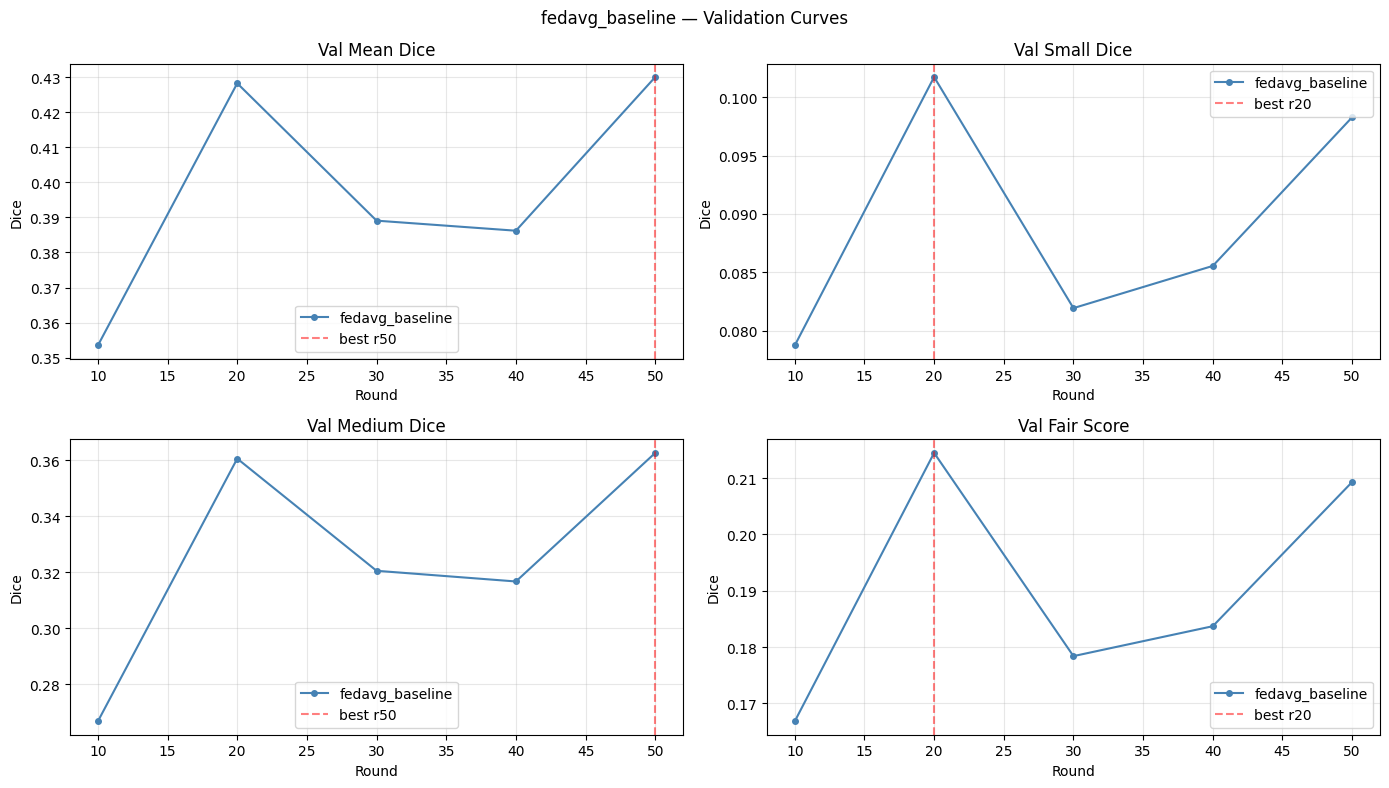

,round,val_mean_dice,val_small_dice,val_medium_dice,val_large_dice,val_fair_score
9,10,0.3535,0.0787,0.2668,0.6517,0.1668
19,20,0.4282,0.1017,0.3606,0.7219,0.2145
29,30,0.3891,0.0819,0.3205,0.6704,0.1784
39,40,0.3862,0.0855,0.3167,0.6738,0.1837
49,50,0.4300,0.0983,0.3626,0.7136,0.2093


Loaded best round 20 | val_fair=0.2145

  FEDAVG_BASELINE — FINAL TEST RESULTS
  mean_dice  : 0.4078
  small_dice : 0.1164
  medium_dice: 0.4131
  large_dice : 0.6938
  fair_score : 0.2408

Per-case breakdown:


,mean,std,min,max,count
size_group,,,,,
large,0.6938,0.1566,0.3011,0.8912,30
medium,0.4131,0.1510,0.1553,0.7420,30
small,0.1164,0.0633,0.0273,0.2461,30


Loading dataset: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


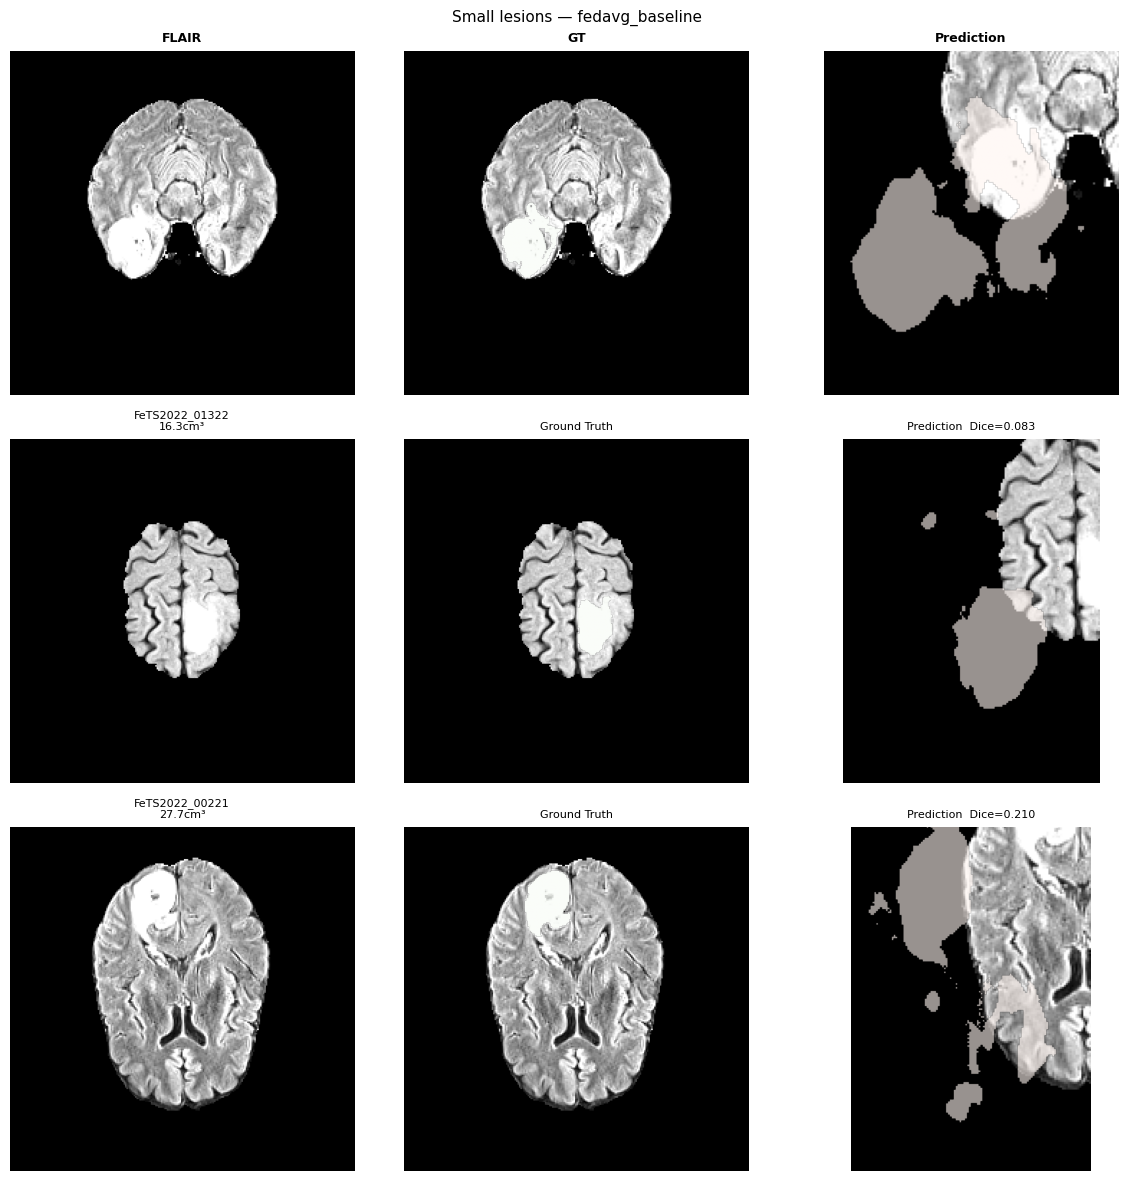

Loading dataset: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


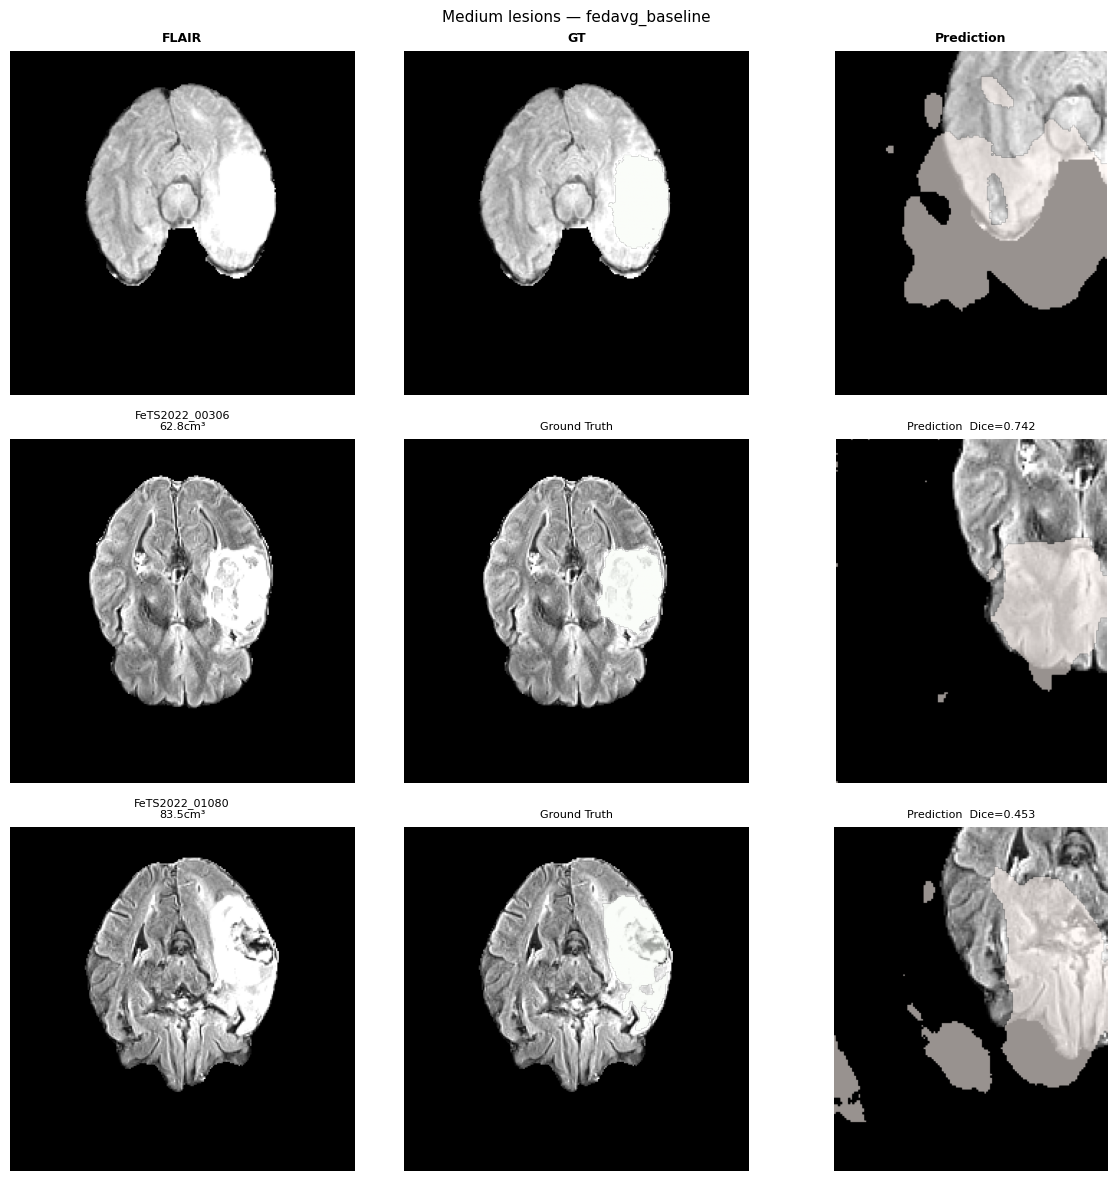

Loading dataset: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


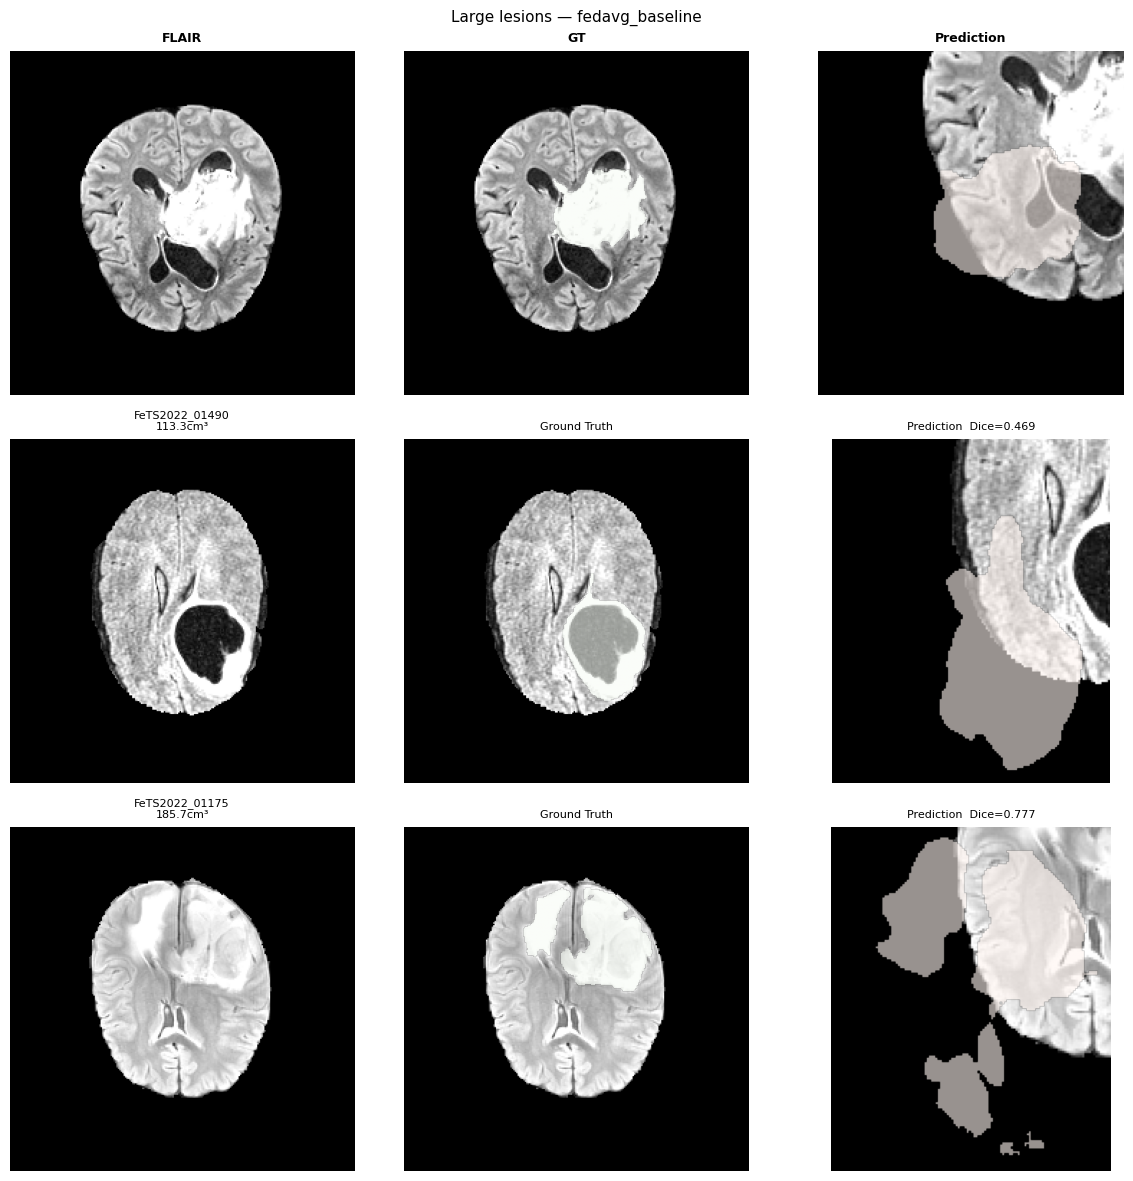


Baseline evaluation complete. All outputs saved to Drive.


In [17]:
# ============================================================
# BASELINE STANDALONE EVALUATION — run immediately after baseline finishes
# Loads from Drive — works after session restart too
# ============================================================
import random as _rnd; _rnd.seed(42)

METHOD = 'fedavg_baseline'
exp_dir  = OUTPUT_DIR / METHOD
ckpt_dir = exp_dir / 'checkpoints'

# ── 1. Training curve ────────────────────────────────────────
hist_df = pd.read_csv(exp_dir / f'{METHOD}_history.csv')
df_v    = hist_df[hist_df['full_val'] == True].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
cols = [('val_mean_dice','Val Mean Dice'),('val_small_dice','Val Small Dice'),
        ('val_medium_dice','Val Medium Dice'),('val_fair_score','Val Fair Score')]
for ax, (col, title) in zip(axes, cols):
    if col in df_v.columns:
        ax.plot(df_v['round'], df_v[col], marker='o', markersize=4, color='steelblue', label=METHOD)
        best_idx = df_v[col].idxmax()
        ax.axvline(df_v.loc[best_idx,'round'], color='red', ls='--', alpha=0.5,
                   label=f'best r{int(df_v.loc[best_idx,"round"])}')
    ax.set_xlabel('Round'); ax.set_ylabel('Dice')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(f'{METHOD} — Validation Curves', fontsize=12)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/f'{METHOD}_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Val metrics table ─────────────────────────────────────
display(df_v[['round','val_mean_dice','val_small_dice',
              'val_medium_dice','val_large_dice','val_fair_score']].round(4))

# ── 3. Load best checkpoint + test inference ─────────────────
ckpt  = torch.load(str(ckpt_dir/f'{METHOD}_best.pt'), map_location=device)
model = get_model()
model.load_state_dict(ckpt['state_dict']); model.eval()
print(f'Loaded best round {ckpt.get("round","?")} | val_fair={ckpt.get("val_fair_score",float("nan")):.4f}')

per_case_rows = []
with torch.inference_mode():
    for batch, rec in zip(test_loader, test_records):
        x = to_dev(batch['image'])
        y = (batch['label'].to(device) > 0).float()
        d = hard_dice(predict_volume(model, x), y)
        per_case_rows.append({'method':METHOD, 'case_name':rec['case_name'],
                              'size_group':rec['size_group'],
                              'lesion_cm3':rec['lesion_cm3'], 'dice':d})

per_case_df = pd.DataFrame(per_case_rows)
per_case_df.to_csv(str(OUTPUT_DIR/f'{METHOD}_per_case_test_dice.csv'), index=False)

# ── 4. Test metrics ───────────────────────────────────────────
def gm(g): v=per_case_df[per_case_df['size_group']==g]['dice']; return v.mean() if len(v) else float('nan')
small, medium, large = gm('small'), gm('medium'), gm('large')
mean_d = per_case_df['dice'].mean()
fair   = harmonic_mean([v for v in [small,medium,large] if not math.isnan(v)])

print(f'\n{"="*50}')
print(f'  {METHOD.upper()} — FINAL TEST RESULTS')
print(f'{"="*50}')
print(f'  mean_dice  : {mean_d:.4f}')
print(f'  small_dice : {small:.4f}')
print(f'  medium_dice: {medium:.4f}')
print(f'  large_dice : {large:.4f}')
print(f'  fair_score : {fair:.4f}')
print(f'{"="*50}')

pd.DataFrame([{'method':METHOD,'best_round':ckpt.get('round','?'),
               'test_mean':mean_d,'test_small':small,
               'test_medium':medium,'test_large':large,'test_fair':fair}
             ]).to_csv(str(OUTPUT_DIR/f'{METHOD}_test_summary.csv'), index=False)

print('\nPer-case breakdown:')
display(per_case_df.groupby('size_group')['dice'].agg(['mean','std','min','max','count']).round(4))

# ── 5. Prediction visualisations ─────────────────────────────
def show_preds_baseline(meta_list, group, n=3):
    cases  = [m for m in meta_list if m['size_group']==group]
    if not cases: return
    chosen = _rnd.sample(cases, min(n, len(cases)))
    fig, axes = plt.subplots(len(chosen), 3, figsize=(12, 4*len(chosen)))
    if len(chosen)==1: axes = np.array([axes])
    fig.suptitle(f'{group.capitalize()} lesions — {METHOD}', fontsize=11)
    for i, meta in enumerate(chosen):
        rec   = resolve_case_files(meta['case_path'])
        flair = nib.load(rec['flair']).get_fdata().astype(np.float32)
        mask  = (nib.load(rec['label']).get_fdata()>0).astype(np.uint8)
        z     = int(np.argmax(mask.sum(axis=(0,1)))) if mask.sum()>0 else flair.shape[2]//2
        lo,hi = np.percentile(flair,1), np.percentile(flair,99)
        img   = np.clip((flair[:,:,z]-lo)/(hi-lo+1e-8), 0, 1)
        axes[i,0].imshow(img.T,cmap='gray',origin='lower')
        axes[i,0].set_title(f'{meta["case_name"]}\n{meta["lesion_cm3"]:.1f}cm³',fontsize=8)
        axes[i,0].axis('off')
        axes[i,1].imshow(img.T,cmap='gray',origin='lower')
        axes[i,1].imshow(np.ma.masked_where(mask[:,:,z].T==0,mask[:,:,z].T),
                         cmap='Greens',alpha=0.6,origin='lower')
        axes[i,1].set_title('Ground Truth',fontsize=8); axes[i,1].axis('off')
        vds = build_eval_dataset([rec])
        vb  = next(iter(build_loader(vds,1,False,workers=0)))
        vx  = to_dev(vb['image']); vy=(vb['label'].to(device)>0).float()
        with torch.inference_mode(): lg=predict_volume(model,vx)
        pred=(torch.sigmoid(lg)[0,0].cpu().numpy()>0.5).astype(np.uint8)
        d=hard_dice(lg,vy)
        axes[i,2].imshow(img.T,cmap='gray',origin='lower')
        axes[i,2].imshow(np.ma.masked_where(pred[:,:,z].T==0,pred[:,:,z].T),
                         cmap='Reds',alpha=0.6,origin='lower')
        axes[i,2].set_title(f'Prediction  Dice={d:.3f}',fontsize=8); axes[i,2].axis('off')
    for ax,h in zip(axes[0],['FLAIR','GT','Prediction']): ax.set_title(h,fontweight='bold',fontsize=9)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR/f'{METHOD}_pred_vis_{group}.png'),dpi=130,bbox_inches='tight')
    plt.show()

for grp in ['small','medium','large']:
    show_preds_baseline(test_meta, grp, n=3)

gc.collect(); torch.cuda.empty_cache()
print('\nBaseline evaluation complete. All outputs saved to Drive.')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()
cols = [('val_mean_dice','Val Mean Dice'),
        ('val_small_dice','Val Small Dice'),
        ('val_medium_dice','Val Medium Dice'),
        ('val_fair_score','Val Fair Score (Harmonic Mean)')]
for ax,(col,title) in zip(axes,cols):
    for mn, out in results.items():
        df = out['history_df']
        df_v = df[df['full_val']==True]
        if col in df_v.columns:
            ax.plot(df_v['round'], df_v[col], marker='o', markersize=3, label=mn)
    ax.set_xlabel('Round'); ax.set_ylabel('Dice')
    ax.set_title(title); ax.legend(); ax.grid(True,alpha=0.3)
plt.suptitle('FedProx+SCWA Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Test summary

In [ ]:
rows = []
for mn, out in results.items():
    tm = out['test']; bv = out['best_val'] or {}
    rows.append({'method': mn, 'best_round': out['best_round'],
                 'best_val_fair': out['best_fair_score'],
                 'test_mean': tm['mean_dice'], 'test_small': tm['small_dice'],
                 'test_medium': tm['medium_dice'], 'test_large': tm['large_dice'],
                 'test_fair': tm['fair_score'], 'test_small_gap': tm['small_gap']})
summary_df = pd.DataFrame(rows).sort_values('test_fair', ascending=False)
display(summary_df.round(4))
summary_df.to_csv(OUTPUT_DIR/'test_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(rows)); w = 0.2
for j,(col,lbl) in enumerate([('test_small','Small'),('test_medium','Medium'),
                                ('test_large','Large'),('test_mean','Mean')]):
    ax.bar(x+j*w, [r[col] for r in rows], w, label=lbl)
ax.set_xticks(x+1.5*w); ax.set_xticklabels([r['method'] for r in rows], rotation=15)
ax.set_ylabel('Dice'); ax.set_title('Test Dice by Group')
ax.legend(); ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'test_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Drive cleanup

Run after training is fully complete.
Deletes `latest.pt` (crash recovery, not needed post-training) and PNG plots (regeneratable).
**Keeps:** `best.pt` + all CSVs (~150MB total).


In [ ]:
for method in EXPERIMENTS_TO_RUN:
    latest = OUTPUT_DIR/method/'checkpoints'/f'{method}_latest.pt'
    if latest.exists():
        os.remove(str(latest)); print(f'Deleted: {latest.name}')
    best = OUTPUT_DIR/method/'checkpoints'/f'{method}_best.pt'
    print(f'Kept: {best.name} ({best.stat().st_size/1e6:.0f} MB)')

for png in OUTPUT_DIR.glob('*.png'):
    os.remove(str(png)); print(f'Deleted: {png.name}')
print('Cleanup done. Drive usage ~150MB.')


## 17. SCWA weight analysis

In [ ]:
alphas = [0.0, 0.3, 0.5, 0.7, 1.0]
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(N_CLIENTS); bw = 0.15
colors = plt.cm.viridis(np.linspace(0.1,0.9,len(alphas)))
for j,(a,col) in enumerate(zip(alphas,colors)):
    w = compute_scwa_weights(n_cases_by_client, n_small_by_client, a)
    tc = sum(w)
    ax.bar(x+j*bw, [wi/tc*100 for wi in w], bw, label=f'alpha={a}', color=col)
ax.set_xticks(x+2*bw)
ax.set_xticklabels([f'Client {i}\n(small={n_small_by_client[i]})' for i in range(N_CLIENTS)])
ax.axhline(100/N_CLIENTS, color='red', ls='--', alpha=0.5, label='Uniform')
ax.set_ylabel('Aggregation Weight (%)'); ax.set_title('SCWA Weight Distribution')
ax.legend(); ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'scwa_weights.png', dpi=150, bbox_inches='tight')
plt.show()


## 18. Post-hoc analysis from checkpoints

**Standalone** — run from a fresh session. Mount Drive, run cells 1-11 (imports through
evaluation functions), then jump here. No retraining needed.

Produces: per-case dice CSV, improvement counts, side-by-side FLAIR|GT|pred visualisations.


In [ ]:
import random as _rnd; _rnd.seed(42)

per_case_rows = []; method_models = {}

for method in EXPERIMENTS_TO_RUN:
    ckpt = OUTPUT_DIR/method/'checkpoints'/f'{method}_best.pt'
    if not ckpt.exists(): print(f'Not found: {ckpt}'); continue
    print(f'Loading {method}...')
    c    = torch.load(str(ckpt), map_location=device)
    m    = get_model(); m.load_state_dict(c['state_dict']); m.eval()
    method_models[method] = m
    print(f'  Round {c.get("round","?")} | fair={c.get("val_fair_score",float("nan")):.4f}')

    print(f'  Inference on {len(test_records)} cases...')
    with torch.inference_mode():
        for batch, rec in zip(test_loader, test_records):
            x = to_dev(batch['image'])
            y = (batch['label'].to(device)>0).float()
            d = hard_dice(predict_volume(m,x), y)
            per_case_rows.append({'method':method,'case_name':rec['case_name'],
                                   'size_group':rec['size_group'],
                                   'lesion_cm3':rec['lesion_cm3'],'dice':d})

per_case_df = pd.DataFrame(per_case_rows)
per_case_df.to_csv(OUTPUT_DIR/'per_case_test_dice.csv', index=False)
display(per_case_df.groupby(['method','size_group'])['dice'].agg(['mean','std','count']).round(4))

if len(EXPERIMENTS_TO_RUN) >= 2:
    m0,m1 = EXPERIMENTS_TO_RUN[0], EXPERIMENTS_TO_RUN[1]
    piv = per_case_df.pivot(index='case_name',columns='method',values='dice').dropna()
    if m0 in piv.columns and m1 in piv.columns:
        piv['improved'] = piv[m1]>piv[m0]; piv['delta'] = piv[m1]-piv[m0]
        piv = piv.join(per_case_df[['case_name','size_group']].drop_duplicates().set_index('case_name'))
        print(f'\nCases where {m1} > {m0}:')
        display(piv.groupby('size_group')['improved'].agg(
            lambda x: f'{int(x.sum())}/{len(x)} ({100*x.mean():.0f}%)'))
        piv.to_csv(OUTPUT_DIR/'per_case_delta.csv')

def show_preds(meta_list, group, n=3):
    cases = [m for m in meta_list if m['size_group']==group]
    if not cases or not method_models: return
    chosen = _rnd.sample(cases, min(n, len(cases)))
    ncols  = 2+len(method_models)
    fig,axes = plt.subplots(len(chosen),ncols,figsize=(4*ncols,4*len(chosen)))
    if len(chosen)==1: axes=np.array([axes])
    fig.suptitle(f'{group.capitalize()} lesion predictions', fontsize=12)
    for i,meta in enumerate(chosen):
        rec   = resolve_case_files(meta['case_path'])
        flair = nib.load(rec['flair']).get_fdata().astype(np.float32)
        mask  = (nib.load(rec['label']).get_fdata()>0).astype(np.uint8)
        z = int(np.argmax(mask.sum(axis=(0,1)))) if mask.sum()>0 else flair.shape[2]//2
        lo,hi = np.percentile(flair,1),np.percentile(flair,99)
        img   = np.clip((flair[:,:,z]-lo)/(hi-lo+1e-8),0,1)
        axes[i,0].imshow(img.T,cmap='gray',origin='lower')
        axes[i,0].set_title(f'{meta["case_name"]}\n{meta["lesion_cm3"]:.1f}cm3',fontsize=8)
        axes[i,0].axis('off')
        axes[i,1].imshow(img.T,cmap='gray',origin='lower')
        axes[i,1].imshow(np.ma.masked_where(mask[:,:,z].T==0,mask[:,:,z].T),
                         cmap='Greens',alpha=0.6,origin='lower')
        axes[i,1].set_title('GT',fontsize=8); axes[i,1].axis('off')
        for j,(mn,mm) in enumerate(method_models.items()):
            vds = build_eval_dataset([rec], f'vis_{mn}')
            vb  = next(iter(build_loader(vds,1,False,workers=0)))
            vx  = to_dev(vb['image']); vy=(vb['label'].to(device)>0).float()
            with torch.inference_mode(): lg=predict_volume(mm,vx)
            pred=(torch.sigmoid(lg)[0,0].cpu().numpy()>0.5).astype(np.uint8)
            d=hard_dice(lg,vy)
            axes[i,2+j].imshow(img.T,cmap='gray',origin='lower')
            axes[i,2+j].imshow(np.ma.masked_where(pred[:,:,z].T==0,pred[:,:,z].T),
                               cmap='Reds',alpha=0.6,origin='lower')
            axes[i,2+j].set_title(f'{mn}\nDice={d:.3f}',fontsize=8)
            axes[i,2+j].axis('off')
    hdrs=['FLAIR','GT']+list(method_models.keys())
    for ax,h in zip(axes[0],hdrs): ax.set_title(h,fontweight='bold',fontsize=9)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR/f'pred_vis_{group}.png'),dpi=130,bbox_inches='tight')
    plt.show()

for grp in ['small','medium','large']:
    show_preds(test_meta, grp, n=3)


## 19. Write-up notes

### Key comparisons
- `fedavg_baseline` vs `fedprox_scwa_a05` — main SCWA contribution
- Primary metric: **test_small_dice** (research question)
- Secondary: **test_fair_score** (harmonic mean — balances all groups)
- Tertiary: **test_mean_dice**

### Story arc
Non-IID Dirichlet partition concentrates small-lesion cases in Client 1 (~12 cases).
FedAvg gives Client 1 the same weight as clients with 0 small cases.
SCWA shifts weight proportionally to small-lesion richness. One hyperparameter.
Computed before round 1. Zero per-round cost. Any small-dice improvement over
baseline is directly attributable to SCWA.

### Privacy note
SCWA uses n_small (case count per client) — one integer shared at setup.
No per-round communication, no inference results, no raw data.
More privacy-preserving than LADS (which transmitted per-round hardship scalars).

### Limitations
- Static weights do not adapt if client distributions change mid-training
- Requires clients to share small-lesion case counts with server at initialisation
- Optimal alpha may vary across datasets
